# Neural Networks with PyTorch
Andres Gonzalez Ojeda 31612


In this activity we will use PyTorch to create a neural network to classify handrawn digits from 0-9. This is a multiclass problem much more complex than the one we did before since we're dealing with images now. The dataset is collected from torchvision.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch
from torchvision import datasets
from torch.utils.data import random_split
from torchvision import datasets
from torchvision.transforms import ToTensor
import torch


First we split our dataset. We're loading the dataset using `datasets.MNIST`. This method automatically splits the dataset into train and "non-train" or test datasets. So we directly split into train and test data with this method and then we take 10,000 observations from the train dataset to create the validation dataset.

In [2]:

full_train = datasets.MNIST(root="data", train=True, download=True, transform=ToTensor())
test_data = datasets.MNIST(root="data", train=False, download=True, transform=ToTensor())

training_data, validation_data = random_split(
    full_train,
    [50_000, 10_000],
    generator=torch.Generator().manual_seed(42)
)

We can plot the dataset counts to verify this.

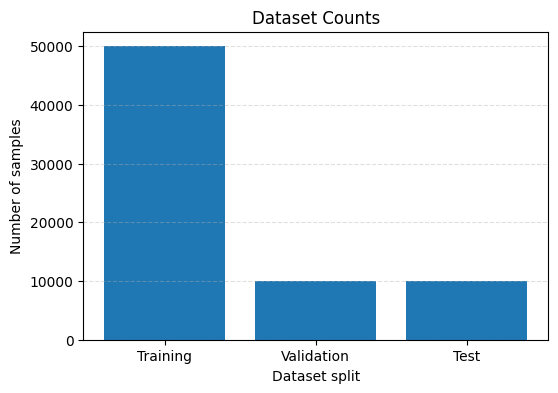

In [3]:
plt.figure(figsize=(6, 4))
dataset_counts = [len(training_data), len(validation_data), len(test_data)]
dataset_labels = ["Training", "Validation", "Test"]
plt.bar(dataset_labels, dataset_counts)
plt.title("Dataset Counts")
plt.ylabel("Number of samples")
plt.xlabel("Dataset split")
plt.grid(axis="y", linestyle="--", alpha=0.4)
plt.show()

Let's also see some of the examples that this dataset has. We'll create a label map to show the actual number in each plot.

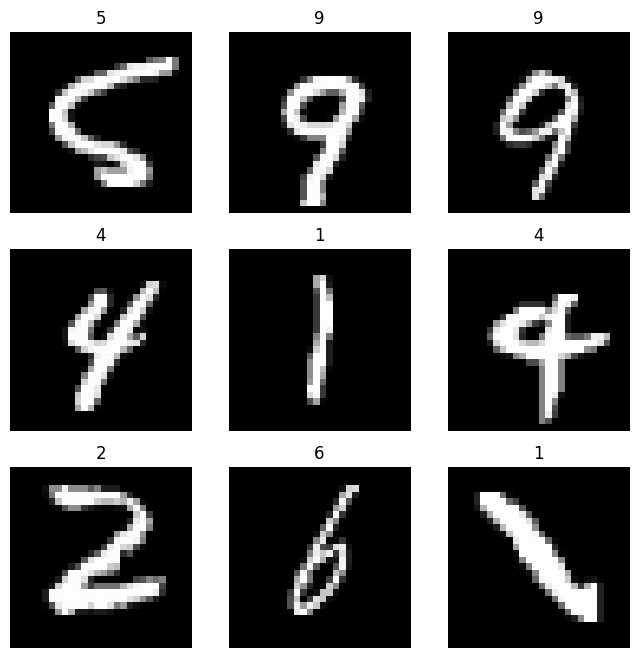

In [4]:
labels_map = {
    0: "0",
    1: "1",
    2: "2",
    3: "3",
    4: "4",
    5: "5",
    6: "6",
    7: "7",
    8: "8",
    9: "9",
}

figure = plt.figure(figsize=(8, 8))
cols, rows = 3, 3
for i in range(1, cols * rows + 1):
    sample_idx = torch.randint(len(training_data), size=(1,)).item()
    img, label = training_data[sample_idx]
    figure.add_subplot(rows, cols, i)
    plt.title(labels_map[label])
    plt.axis("off")
    plt.imshow(img.squeeze(), cmap="gray")
plt.show()

We will create a FeedForwardNN that has no set arguments so that we can use the networks list to try multiple network configurations. We use a for loop inside of forward to take into account all the layers used. 

We describe 3 networks, the first has two hidden layers with adam optimizer, a learning rate of 0.001 and batch size of 32. 

The second network is exactly the same but now we added an additional layer at the front that has twice as many neurons, I want to see how much improvement we get just by changing the layers.

Finally we have a very similar arquitecture to the second but now we use sgd optimizer with a much faster learning rate of 0.01 and a batch size of 64 just to experiment.

In [ ]:
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader

networks = [
    { "name": "Net1", "hidden": [128, 64], "optimizer": "adam", "lr": 0.001, "batch_size": 32, "epochs": 15 },
    { "name": "Net2", "hidden": [256, 128, 64], "optimizer": "adam", "lr": 0.001, "batch_size": 32, "epochs": 15 },
    { "name": "Net3", "hidden": [256, 128, 64], "optimizer":  "sgd", "lr": 0.01, "batch_size": 64, "epochs": 15 }
]

class FeedForwardNN(nn.Module):
    def __init__(self, hidden_sizes):
        super().__init__()
        sizes = [784] + hidden_sizes + [10]
        self.layers = nn.ModuleList([
            nn.Linear(sizes[i], sizes[i+1]) for i in range(len(sizes)-1)
        ])

    def forward(self, x):
        x = x.view(x.shape[0], -1)
        for layer in self.layers[:-1]:
            x = torch.relu(layer(x))
        x = self.layers[-1](x)
        return x

We create aan evaluate function that just calculates the average loss and accuracy without updating the model weiights. This will be used later.

In [6]:
def evaluate(model, loader, loss_fn):
    model.eval()
    total_loss = 0
    correct = 0
    with torch.no_grad():
        for X_batch, y_batch in loader:
            output = model(X_batch)
            total_loss += loss_fn(output, y_batch).item()
            correct += (output.argmax(1) == y_batch).sum().item()
    avg_loss = total_loss / len(loader)
    accuracy = correct / len(loader.dataset)
    return avg_loss, accuracy


We create a loop that iterates through our three networks. Here we call FeedForwardNN and give the hidden sizes from the specify network. Applying the loss for backpropagation also.

Then we set the optimizers and we train with a loop that iterates thorugh all the epochs and adjust per batch.

Then we evaluate the model with the validation dataset and here's where we implement early stopping with abs(loss(n-patience) - loss(n)) < delta.

Then we append the results of each model.

In [7]:
val_loader  = DataLoader(validation_data,  batch_size=256, shuffle=False)
test_loader = DataLoader(test_data, batch_size=256, shuffle=False)

results = []

patience = 1
delta = 0.05
val_loss_history = []
stopped_early = False
for net in networks:
    print(f"\n- {net['name']}")

    model   = FeedForwardNN(hidden_sizes=net["hidden"])
    loss_fn = nn.CrossEntropyLoss()

    if net["optimizer"] == "adam":
        optimizer = optim.Adam(model.parameters(), lr=net["lr"])
    elif net["optimizer"] == "sgd":
        optimizer = optim.SGD(model.parameters(), lr=net["lr"])

    train_loader = DataLoader(training_data, batch_size=net["batch_size"], shuffle=True)

    prev_val_loss = None
    stopped_early = False

    # train per network
    for epoch in range(net["epochs"]):
        model.train()
        for X_batch, y_batch in train_loader:
            output = model(X_batch)
            loss = loss_fn(output, y_batch)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

        val_loss, val_acc = evaluate(model, val_loader, loss_fn)
        print(f"  Epoch {epoch + 1}/{net['epochs']}  val_loss={val_loss}  val_acc={val_acc}")

        # early stopping

        if patience < len(val_loss_history):
            last = val_loss_history[-patience - 1]
            current = val_loss_history[-1]
            if last >= current and abs(last - current) < delta:
                print(f"  Stopped early at {epoch + 1}")
                stopped_early = True
                break

        prev_val_loss = val_loss

    # save results
    results.append({
        "name": net["name"],
        "val_loss": val_loss,
        "val_acc": val_acc,
        "stopped_early": stopped_early
    })



- Net1
  Epoch 1/15  val_loss=0.17341819871217012  val_acc=0.9472
  Epoch 2/15  val_loss=0.12664559334516526  val_acc=0.9612
  Epoch 3/15  val_loss=0.10651973311323673  val_acc=0.967
  Epoch 4/15  val_loss=0.11218557180836797  val_acc=0.9659
  Epoch 5/15  val_loss=0.10085653884452768  val_acc=0.9697
  Epoch 6/15  val_loss=0.09224093455122784  val_acc=0.9737
  Epoch 7/15  val_loss=0.10389435609249631  val_acc=0.9705
  Epoch 8/15  val_loss=0.09510569956473773  val_acc=0.9729
  Epoch 9/15  val_loss=0.10715944948315155  val_acc=0.9726
  Epoch 10/15  val_loss=0.09601979435101385  val_acc=0.9752
  Epoch 11/15  val_loss=0.1052642189519247  val_acc=0.9752
  Epoch 12/15  val_loss=0.11070391811445006  val_acc=0.9747
  Epoch 13/15  val_loss=0.12659837251121644  val_acc=0.9713
  Epoch 14/15  val_loss=0.1205964860651875  val_acc=0.9732
  Epoch 15/15  val_loss=0.11336066322110128  val_acc=0.975

- Net2
  Epoch 1/15  val_loss=0.16251527089625598  val_acc=0.952
  Epoch 2/15  val_loss=0.10203530183061

We can see that network 1 and 2 had very similar results but network 2 did get the top result considerably faster. Network 3 had the worst results, probably because we adjusted a lot of it's hyperparaters.

We calculate finally the best model taking it from the results array.

In [8]:
best = max(results, key=lambda x: x["val_acc"])
print(f"\nBest model: {best['name']}")

test_loss, test_acc = evaluate(model, test_loader, loss_fn)
print(f"Test loss: {test_loss}  Test accuracy: {test_acc}")


Best model: Net2
Test loss: 0.1577924048062414  Test accuracy: 0.9521


We finally plot some of the images to see how our model stands up against test examples. 

(Used copilot for this plot)

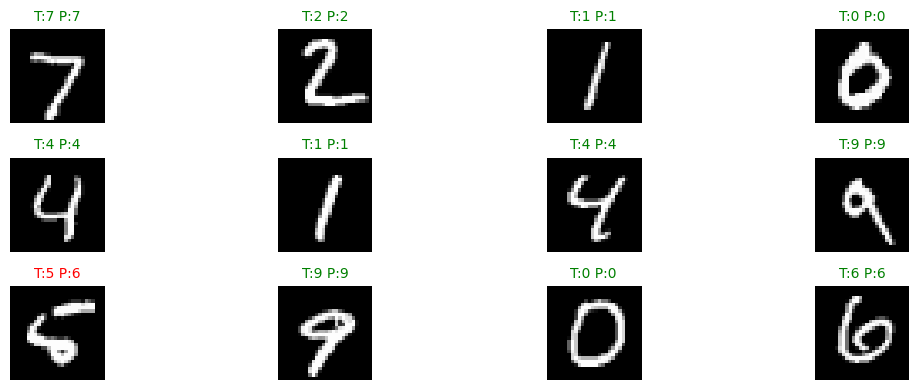

In [9]:
model.eval()

X_vis, y_vis = next(iter(test_loader))
with torch.no_grad():
    logits = model(X_vis)
    y_pred = logits.argmax(dim=1)

n = 12
plt.figure(figsize=(12, 4))
for j in range(n):
    plt.subplot(3, 4, j + 1)
    plt.imshow(X_vis[j].squeeze(), cmap="gray")
    true_label = int(y_vis[j].item())
    pred_label = int(y_pred[j].item())
    color = "green" if true_label == pred_label else "red"
    plt.title(f"T:{labels_map[true_label]} P:{labels_map[pred_label]}", color=color, fontsize=10)
    plt.axis("off")

plt.tight_layout()
plt.show()

## Conclusion

This activity was really interesting. Personally I had never worked with PyTorch and it's interesting how everything is implemented through classes, feels more customizable than something like tensorflow for example.

References:

https://docs.pytorch.org/tutorials/beginner/basics/data_tutorial.html

https://docs.pytorch.org/docs/2.10/generated/torch.nn.ModuleList.html